In [1]:
!pip install kagglehub mediapipe opencv-python pandas

import kagglehub

# Tải phiên bản mới nhất của dataset
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Đường dẫn đến bộ dữ liệu:", path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
Using Colab cache for faster access to the 'asl-alphabet' dataset.
Đường dẫn đến bộ dữ liệu: /kaggle/input/asl-alphabet


In [2]:
pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.33
    Uninstalling mediapipe-0.10.33:
      Successfully uninstalled mediapipe-0.10.33
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires

#1. Trích xuất tọa độ ra csv

In [3]:
import os
import cv2
import mediapipe as mp
import pandas as pd
from mediapipe.python.solutions.hands import Hands
from tqdm.notebook import tqdm # Thư viện tạo thanh tiến trình cho Colab

# 1. Khởi tạo MediaPipe
hands = Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

# 2. Cài đặt số lượng ảnh thông minh
weak_labels = {
    'M': 3000, 'N': 3000, 'U': 3000, 'V': 3000,
    'S': 3000, 'T': 3000, 'E': 3000, 'nothing': 3000
}
DEFAULT_COUNT = 1500

# 3. Đường dẫn
DATASET_TRAIN_PATH = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
if not os.path.exists(DATASET_TRAIN_PATH):
    DATASET_TRAIN_PATH = os.path.join(path, 'asl_alphabet_train')

output_data = []
labels = sorted(os.listdir(DATASET_TRAIN_PATH))

print(f"--- BẮT ĐẦU TRÍCH XUẤT THÔNG MINH CÓ THANH TIẾN TRÌNH ---")

# Vòng lặp lớn cho từng thư mục chữ cái
for label in labels:
    label_path = os.path.join(DATASET_TRAIN_PATH, label)
    if not os.path.isdir(label_path): continue

    target_count = weak_labels.get(label, DEFAULT_COUNT)
    images = os.listdir(label_path)[:target_count]

    count = 0
    # BỔ SUNG: tqdm bọc quanh danh sách ảnh để tạo thanh tiến trình
    # desc: Tiêu đề hiển thị | unit: đơn vị đếm (ảnh)
    pbar = tqdm(images, desc=f"Đang xử lý chữ {label}", unit="img")

    for img_name in pbar:
        img_path = os.path.join(label_path, img_name)
        image = cv2.imread(img_path)
        if image is None: continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = hands.process(image_rgb)

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                x0, y0 = hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y

                # Gốc & Mirror
                row = []
                mirror_row = []
                for lm in hand_landmarks.landmark:
                    # Gốc
                    row.append(lm.x - x0)
                    row.append(lm.y - y0)
                    # Mirror
                    mirror_row.append(-(lm.x - x0))
                    mirror_row.append(lm.y - y0)

                row.append(label)
                mirror_row.append(label)
                output_data.append(row)
                output_data.append(mirror_row)
                count += 1

        # Cập nhật thông tin bổ sung vào thanh tiến trình
        pbar.set_postfix({"Thành công": count})

# 4. Lưu CSV
cols = [f'{c}{i}' for i in range(21) for c in ['x', 'y']] + ['label']
df = pd.DataFrame(output_data, columns=cols)
df.to_csv('asl_coordinates_smart_v2.csv', index=False)
print("\n--- HOÀN THÀNH XUẤT SẮC! ---")

--- BẮT ĐẦU TRÍCH XUẤT THÔNG MINH CÓ THANH TIẾN TRÌNH ---


Đang xử lý chữ A:   0%|          | 0/1500 [00:00<?, ?img/s]

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Đang xử lý chữ B:   0%|          | 0/1500 [00:00<?, ?img/s]

Đang xử lý chữ C:   0%|          | 0/1500 [00:00<?, ?img/s]

...

Đang xử lý chữ Z:   0%|          | 0/1500 [00:00<?, ?img/s]

Đang xử lý chữ del:   0%|          | 0/1500 [00:00<?, ?img/s]

Đang xử lý chữ nothing:   0%|          | 0/3000 [00:00<?, ?img/s]

Đang xử lý chữ space:   0%|          | 0/1500 [00:00<?, ?img/s]


--- HOÀN THÀNH XUẤT SẮC! ---


#2. Huấn luyện mô hình

--- Đang huấn luyện Random Forest (v2)... ---

ĐỘ CHÍNH XÁC TỔNG THỂ: 99.39%


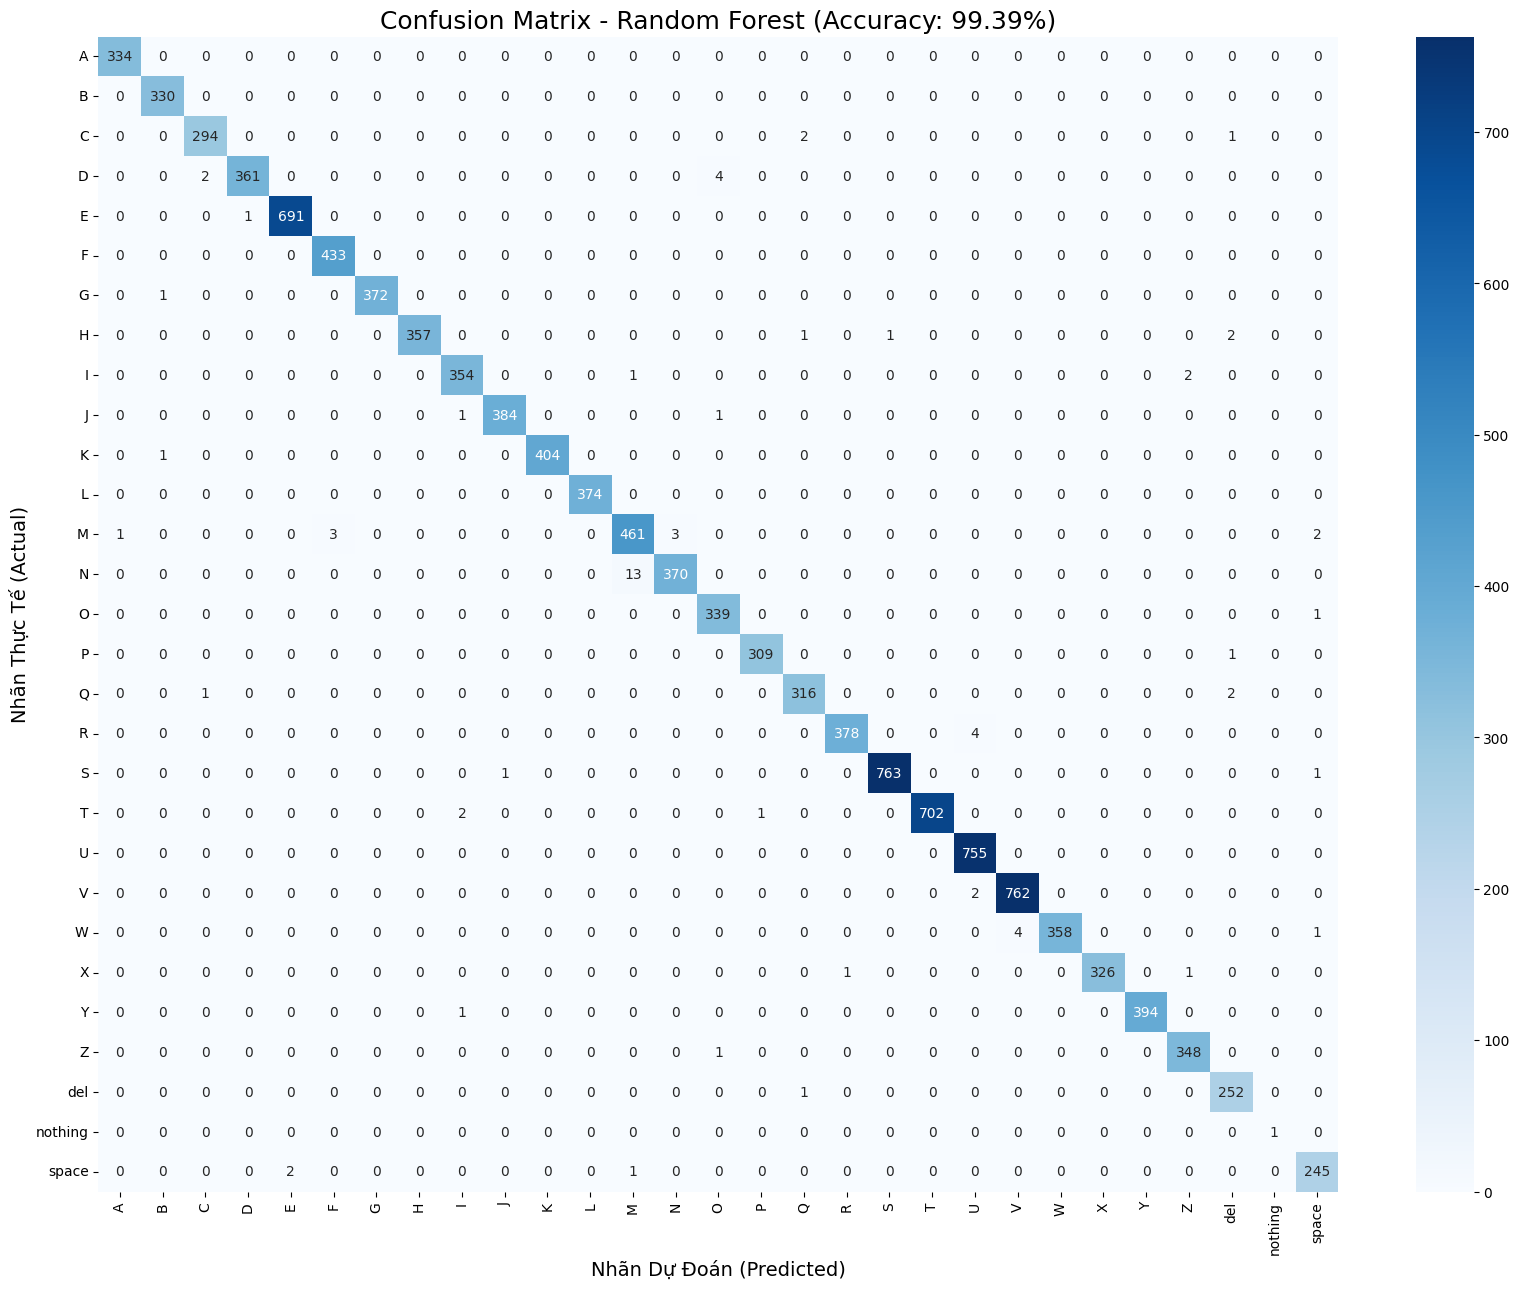


BÁO CÁO CHI TIẾT (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       334
           B       0.99      1.00      1.00       330
           C       0.99      0.99      0.99       297
           D       1.00      0.98      0.99       367
           E       1.00      1.00      1.00       692
           F       0.99      1.00      1.00       433
           G       1.00      1.00      1.00       373
           H       1.00      0.99      0.99       361
           I       0.99      0.99      0.99       357
           J       1.00      0.99      1.00       386
           K       1.00      1.00      1.00       405
           L       1.00      1.00      1.00       374
           M       0.97      0.98      0.97       470
           N       0.99      0.97      0.98       383
           O       0.98      1.00      0.99       340
           P       1.00      1.00      1.00       310
           Q       0.99      0.9

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# 1. Đọc dữ liệu
df = pd.read_csv('asl_coordinates_smart_v2.csv')
X = df.drop('label', axis=1)
y = df['label']

# 2. Chia tập dữ liệu (stratify giúp giữ nguyên tỉ lệ các lớp chữ cái)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# 3. Huấn luyện mô hình tối ưu
rf_model = RandomForestClassifier(n_estimators=300,
                                  max_depth=None,
                                  min_samples_split=2,
                                  random_state=42,
                                  n_jobs=-1)

print("--- Đang huấn luyện Random Forest (v2)... ---")
rf_model.fit(X_train, y_train)

# 4. Đánh giá và Dự đoán
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nĐỘ CHÍNH XÁC TỔNG THỂ: {acc*100:.2f}%")

# 5. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
plt.figure(figsize=(20, 15))
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.title(f'Confusion Matrix - Random Forest (Accuracy: {acc*100:.2f}%)', fontsize=18)
plt.xlabel('Nhãn Dự Đoán (Predicted)', fontsize=14)
plt.ylabel('Nhãn Thực Tế (Actual)', fontsize=14)
plt.show()

# 6. In báo cáo chi tiết từng lớp
print("\nBÁO CÁO CHI TIẾT (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred))

# 7. Lưu mô hình
joblib.dump(rf_model, 'RD.pkl')
print("--- Đã lưu file RD.pkl thành công! ---")

```markdown
### 3. Mã kiểm thử thời gian thực (Chạy trên máy local)

Vì Google Colab chạy trên cloud nên không thể mở cửa sổ webcam trực tiếp bằng `cv2.imshow()`. Bạn nên copy đoạn code dưới đây vào một file Python (ví dụ `test_cam.py`) trên máy tính có cài đặt webcam, đặt file `RD.pkl` cùng thư mục để test.
```

In [6]:
# Đoạn code này dùng để chạy trên máy cá nhân (Local PC)
import cv2
import mediapipe as mp
import joblib
import numpy as np

# 1. Tải mô hình đã huấn luyện
model = joblib.load('RD.pkl')

# 2. Khởi tạo MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)

print("Đang mở Camera... Nhấn 'q' để thoát.")

while cap.isOpened():
    success, image = cap.read()
    if not success: break

    # Lật ảnh và chuyển sang RGB
    image = cv2.flip(image, 1)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Vẽ landmarks lên tay
            mp_draw.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            # Trích xuất tọa độ tương tự lúc train
            lm_list = []
            x0, y0 = hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y
            for lm in hand_landmarks.landmark:
                lm_list.append(lm.x - x0)
                lm_list.append(lm.y - y0)

            # Dự đoán
            prediction = model.predict([lm_list])
            label = prediction[0]

            # Hiển thị kết quả
            cv2.putText(image, f'Chu cai: {label}', (50, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 2)

    cv2.imshow('ASL Recognition Test', image)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Đang mở Camera... Nhấn 'q' để thoát.


### 4. Demo Webcam trực tiếp trên Colab (Sử dụng Javascript)